# Supervised Fine-Tuning Experiment

> Historical experiment retained for reproducibility; not used by the production pipeline. Set `HF_TOKEN` and `WANDB_TOKEN` in Colab Secrets. The trained model is published to the Hugging Face account associated with `HF_TOKEN`.

## 1. Install Dependencies & Import Libraries

In [1]:
!pip install -q unsloth
!pip install -q transformers datasets accelerate bitsandbytes trl peft
!pip install -q wandb huggingface_hub

In [2]:
import os
import torch
import wandb
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from unsloth import FastLanguageModel

print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


# 2. Login Hugging Face & WandB

In [3]:
from google.colab import userdata
from huggingface_hub import HfApi, login
import wandb

HF_TOKEN = userdata.get("HF_TOKEN")
WANDB_TOKEN = userdata.get("WANDB_TOKEN")
OUTPUT_MODEL_ID = f"{HfApi().whoami(token=HF_TOKEN)['name']}/legal-chatbot-qwen-sft"

login(HF_TOKEN)
wandb.login(key=WANDB_TOKEN)

wandb.init(
    project="legal-chatbot-qwen25-sft",
    name="qwen25-3b-qlora-sft",
    reinit=True
)

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


# 3. Load Model + LoRA Configuration

In [4]:
max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

print("Model + LoRA siap")

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model + LoRA siap


# 4. Load Dataset

In [5]:
dataset_raw = load_dataset(
    "Ichsan2895/alpaca-gpt4-indonesian",
    split="train"
)

print(dataset_raw)
print(dataset_raw.column_names)

df = dataset_raw.to_pandas()

input_lengths = df["input"].astype(str).apply(len)
output_lengths = df["output"].astype(str).apply(len)

print(df.head())

print(
    f"""
Jumlah Data      : {len(df)}
Rata-rata Input  : {input_lengths.mean():.2f}
Rata-rata Output : {output_lengths.mean():.2f}
"""
)

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})
['Unnamed: 0', 'input', 'output']
   Unnamed: 0                                              input  \
0           1        Saranlah slogan untuk kampanye daur ulang\n   
1           3  Ciptakan cara unik dan lucu untuk menggambarka...   
2           5  Diberikan deskripsi tentang peristiwa pribadi,...   
3           7  Tulislah satu paragraf sepanjang 100 kata meng...   
4           9  Anda dapat merangkum deskripsi/paragraf yang d...   

                                              output  
0  1. "Kurangi, gunakan kembali, daur ulang: Bers...  
1  Sebagai AI, saya tidak tergabung dalam satu ne...  
2  Lautan membiru cemerlang\nTerang matahari di a...  
3  Pendidikan Sains membentuk dasar berpikir krit...  
4  Secara singkat, roket adalah wahana antariksa ...  

Jumlah Data      : 49969
Rata-rata Input  : 94.31
Rata-rata Output : 720.59



# 5. Visualisasi Dataset

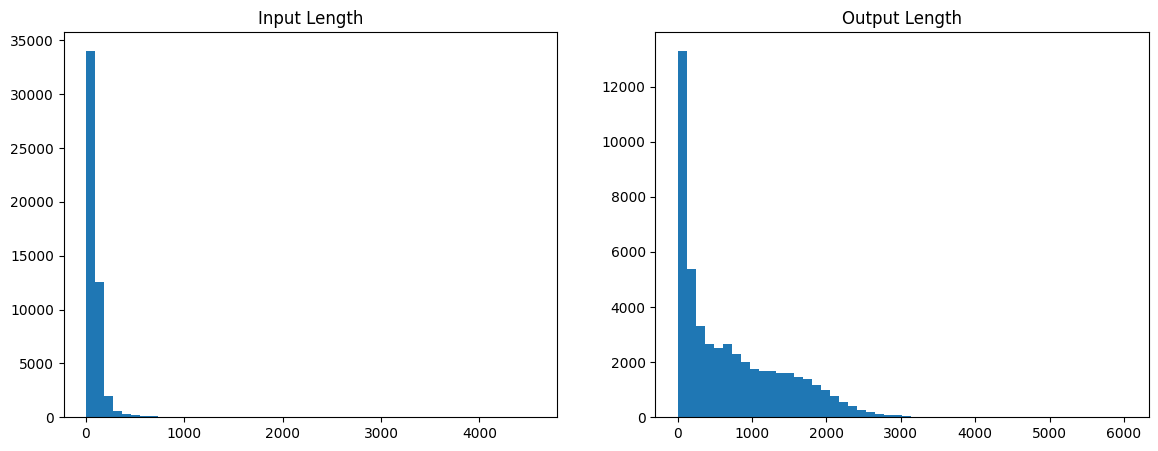

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(input_lengths, bins=50)
axes[0].set_title("Input Length")

axes[1].hist(output_lengths, bins=50)
axes[1].set_title("Output Length")

plt.show()

# 6. Chat Template Mapping

In [7]:
qwen_prompt = """<|im_start|>system
Kamu adalah asisten AI hukum yang membantu menjawab pertanyaan pengguna secara akurat berdasarkan hukum Indonesia.<|im_end|>
<|im_start|>user
{}<|im_end|>
<|im_start|>assistant
{}<|im_end|>"""

def formatting_prompts_func(examples):

    texts = []

    for inp, out in zip(
        examples["input"],
        examples["output"]
    ):
        texts.append(
            qwen_prompt.format(inp, out)
        )

    return {"text": texts}

dataset_mapped = dataset_raw.map(
    formatting_prompts_func,
    batched=True
)

print(dataset_mapped[0]["text"])

Map:   0%|          | 0/49969 [00:00<?, ? examples/s]

<|im_start|>system
Kamu adalah asisten AI hukum yang membantu menjawab pertanyaan pengguna secara akurat berdasarkan hukum Indonesia.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang
<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>


# 7. Train/Validation Split

In [8]:
dataset_split = dataset_mapped.train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

print(
    f"Train: {len(train_dataset)} | "
    f"Eval: {len(eval_dataset)}"
)

Train: 44972 | Eval: 4997


# 8. Training Configuration + Trainer

In [9]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="outputs_qwen_sft",

    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    warmup_steps=50,

    max_steps=800,

    learning_rate=2e-4,

    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    logging_steps=5,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="no",

    report_to="wandb",

    weight_decay=0.01,

    seed=3407,

    dataset_text_field="text",

    max_seq_length=max_seq_length,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,

    train_dataset=train_dataset,
    eval_dataset=eval_dataset,

    args=training_args,

    packing=False,
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4997 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


# 9. Training

In [10]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.120398,1.085636
200,1.112646,1.067809
300,1.164051,1.059184
400,1.068120,1.050498
500,1.005766,1.043866
600,1.025778,1.039543
700,1.098623,1.035504
800,1.010989,1.033803


# 10. Push ke Hugging Face

In [ ]:
model.push_to_hub_merged(
    OUTPUT_MODEL_ID,
    tokenizer,
    save_method="merged_16bit",
    token=HF_TOKEN
)

In [13]:
wandb.finish()

eval/loss,█▆▄▃▂▂▁▁▁
eval/runtime,▇▇▇▇▇▇██▁
eval/samples_per_second,▂▂▂▂▂▂▁▁█
eval/steps_per_second,▁▂▂▂▂▂▁▁█
train/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
train/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇██
train/grad_norm,▄█▃▂▁▂▂▂▂▁▂▂▁▂▂▁▂▁▁▂▂▂▂▂▁▁▂▂▂▁▂▁▁▂▂▂▂▁▃▃
train/learning_rate,▁▅▆████▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
train/loss,█▂▃▂▂▂▂▁▂▂▂▂▂▂▂▂▂▁▁▂▂▁▂▃▂▂▁▂▂▂▂▂▁▂▂▂▂▂▁▁
eval/loss,1.0338
eval/runtime,682.9539
